In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler  
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df = pd.read_csv(r"C:\Users\Pratyasha\Downloads\E Commerce Dataset (1).csv")
from sklearn.ensemble import RandomForestClassifier
df.info

<bound method DataFrame.info of       CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  \
0          50001      1     4.0         Mobile Phone         3   
1          50002      1     NaN                Phone         1   
2          50003      1     NaN                Phone         1   
3          50004      1     0.0                Phone         3   
4          50005      1     0.0                Phone         1   
...          ...    ...     ...                  ...       ...   
5625       55626      0    10.0             Computer         1   
5626       55627      0    13.0         Mobile Phone         1   
5627       55628      0     1.0         Mobile Phone         1   
5628       55629      0    23.0             Computer         3   
5629       55630      0     8.0         Mobile Phone         1   

      WarehouseToHome PreferredPaymentMode  Gender  HourSpendOnApp  \
0                 6.0           Debit Card  Female             3.0   
1                 8.0              

In [3]:
df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [4]:
df.drop('CustomerID', axis=1, inplace=True, errors='ignore')

df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace('Phone', 'Mobile Phone')
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace('COD', 'Cash on Delivery')

df['Tenure'] = df['Tenure'].fillna(df['Tenure'].median())
df['WarehouseToHome'] = df['WarehouseToHome'].fillna(df['WarehouseToHome'].median())
df['HourSpendOnApp'] = df['HourSpendOnApp'].fillna(df['HourSpendOnApp'].median())
df['OrderAmountHikeFromlastYear'] = df['OrderAmountHikeFromlastYear'].fillna(df['OrderAmountHikeFromlastYear'].median())
df['CouponUsed'] = df['CouponUsed'].fillna(0)
df['OrderCount'] = df['OrderCount'].fillna(df['OrderCount'].median())
df['DaySinceLastOrder'] = df['DaySinceLastOrder'].fillna(df['DaySinceLastOrder'].median())

df = pd.get_dummies(df, drop_first=True)

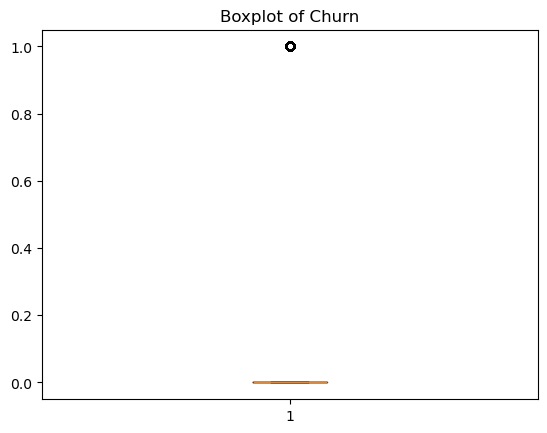

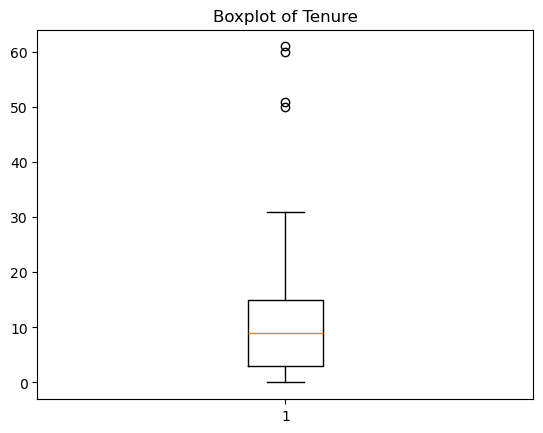

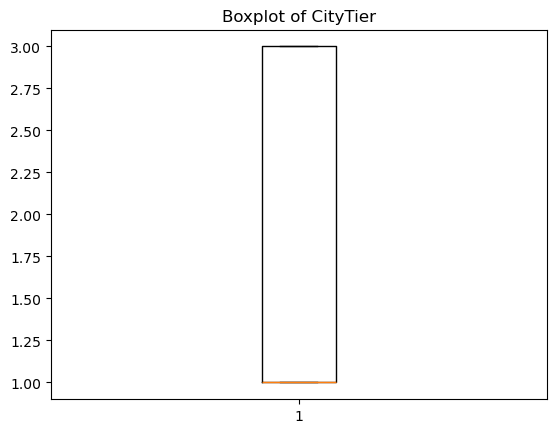

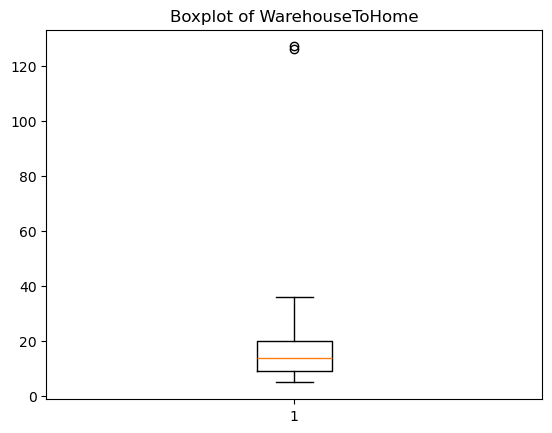

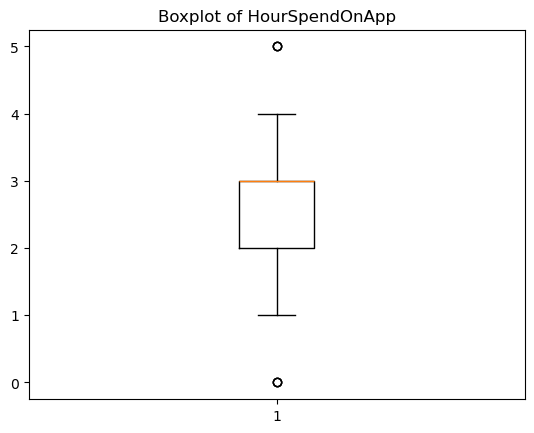

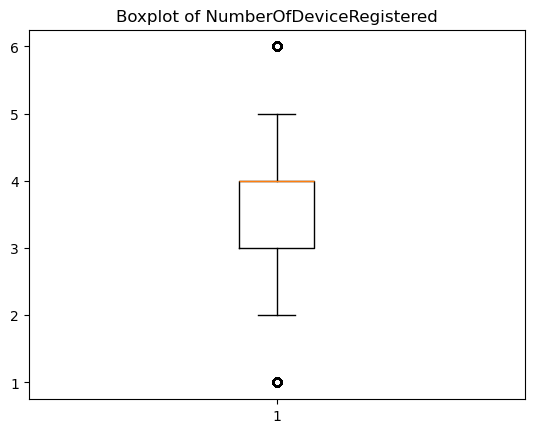

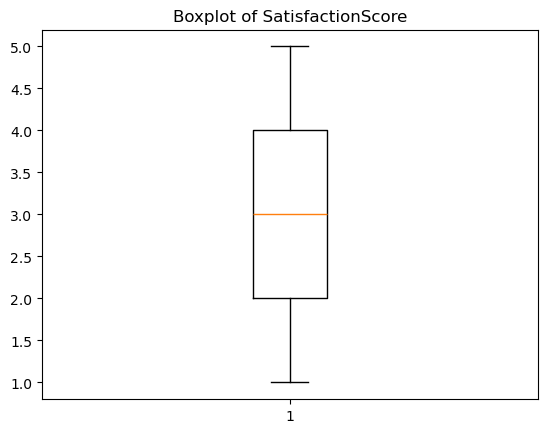

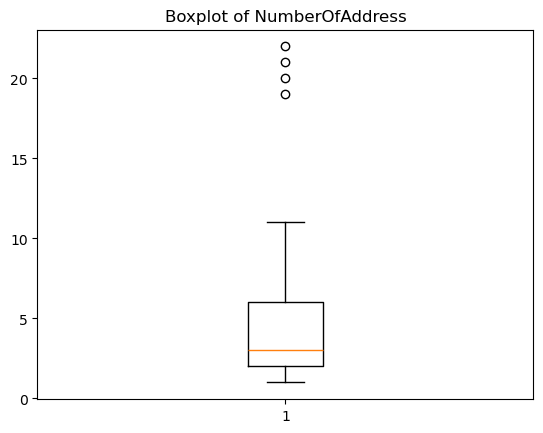

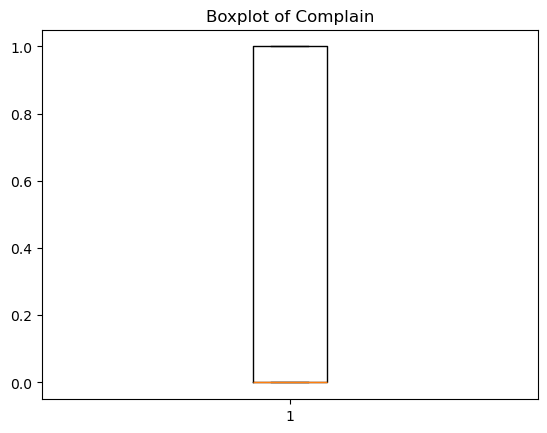

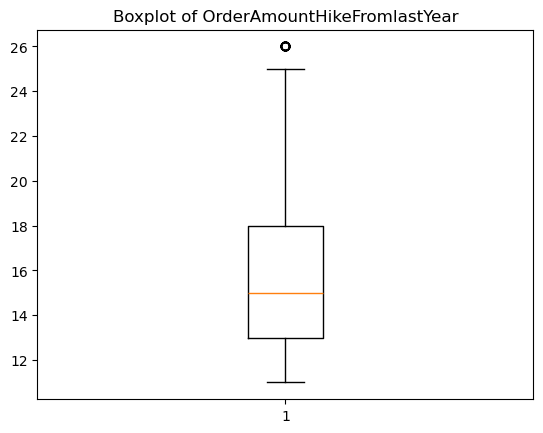

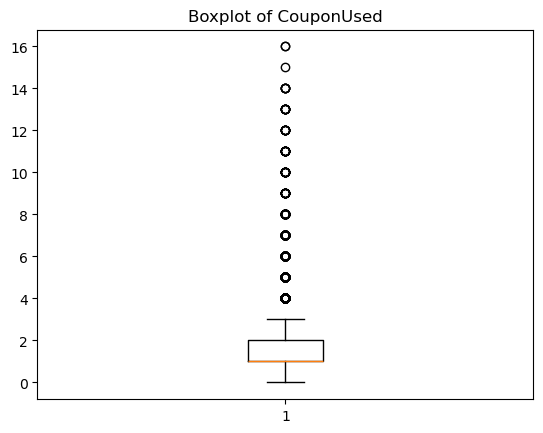

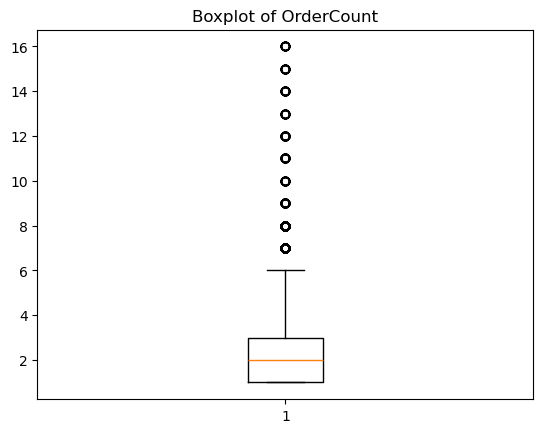

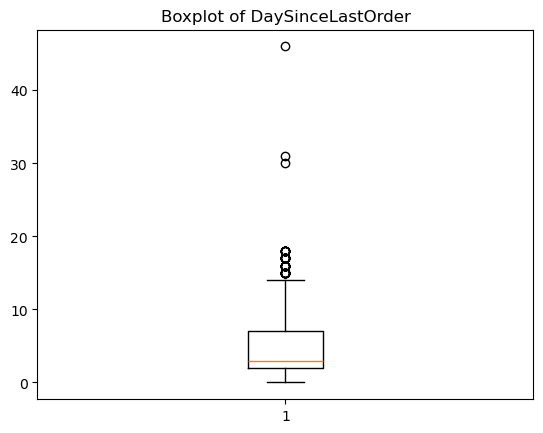

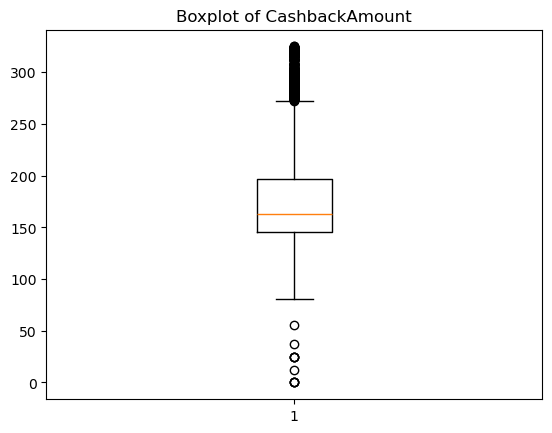

In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

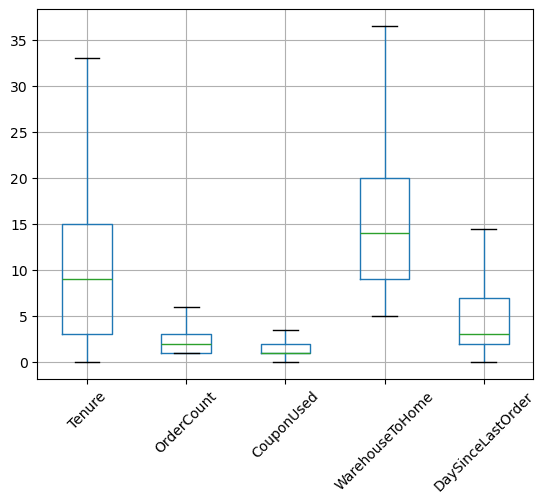

In [26]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
   
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df


outlier_cols = ['Tenure', 'OrderCount', 'CouponUsed', 'WarehouseToHome', 'DaySinceLastOrder']
for col in outlier_cols:
    df = cap_outliers(df, col)


import matplotlib.pyplot as plt
df[outlier_cols].boxplot()
plt.xticks(rotation=45)
plt.show()

In [27]:
df.info

<bound method DataFrame.info of       Churn  Tenure  CityTier  WarehouseToHome  HourSpendOnApp  \
0         1     4.0         3              6.0             3.0   
1         1     9.0         1              8.0             3.0   
2         1     9.0         1             30.0             2.0   
3         1     0.0         3             15.0             2.0   
4         1     0.0         1             12.0             3.0   
...     ...     ...       ...              ...             ...   
5625      0    10.0         1             30.0             3.0   
5626      0    13.0         1             13.0             3.0   
5627      0     1.0         1             11.0             3.0   
5628      0    23.0         3              9.0             4.0   
5629      0     8.0         1             15.0             3.0   

      NumberOfDeviceRegistered  SatisfactionScore  NumberOfAddress  Complain  \
0                            3                  2                9         1   
1              

In [28]:
df = df.astype(int)

In [29]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [30]:
df.info

<bound method DataFrame.info of       Churn  Tenure  CityTier  WarehouseToHome  HourSpendOnApp  \
0         1       4         3                6               3   
1         1       9         1                8               3   
2         1       9         1               30               2   
3         1       0         3               15               2   
4         1       0         1               12               3   
...     ...     ...       ...              ...             ...   
5625      0      10         1               30               3   
5626      0      13         1               13               3   
5627      0       1         1               11               3   
5628      0      23         3                9               4   
5629      0       8         1               15               3   

      NumberOfDeviceRegistered  SatisfactionScore  NumberOfAddress  Complain  \
0                            3                  2                9         1   
1              

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

NameError: name 'X' is not defined

Final Accuracy: 97.25%


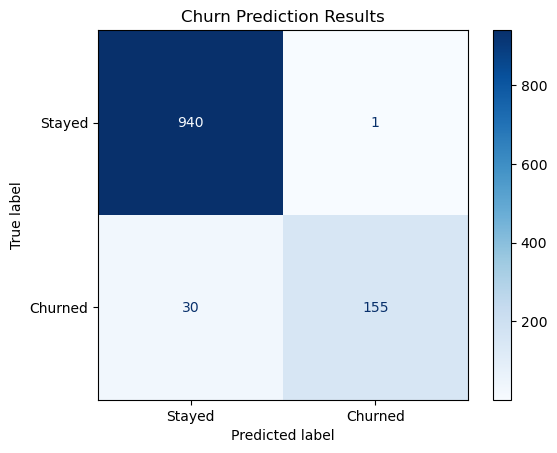


Detailed Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       941
           1       0.99      0.84      0.91       185

    accuracy                           0.97      1126
   macro avg       0.98      0.92      0.95      1126
weighted avg       0.97      0.97      0.97      1126



In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.2%}")

# Show Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Churn Prediction Results')
plt.show()

# Show text report
print("\nDetailed Report:\n", classification_report(y_test, y_pred))

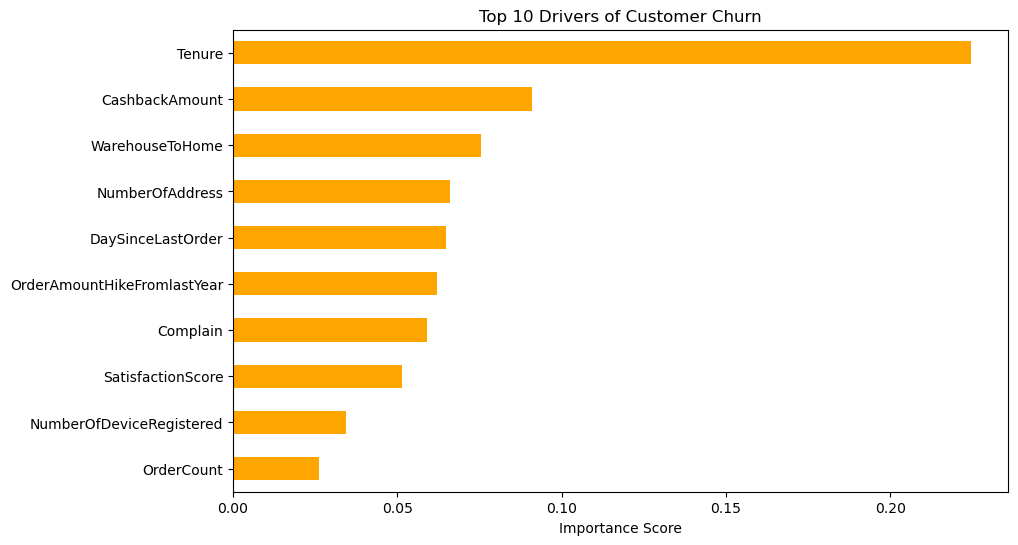

In [34]:
# Get feature importances from the model
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
importances.nlargest(10).sort_values().plot(kind='barh', color='orange')
plt.title('Top 10 Drivers of Customer Churn')
plt.xlabel('Importance Score')
plt.show()

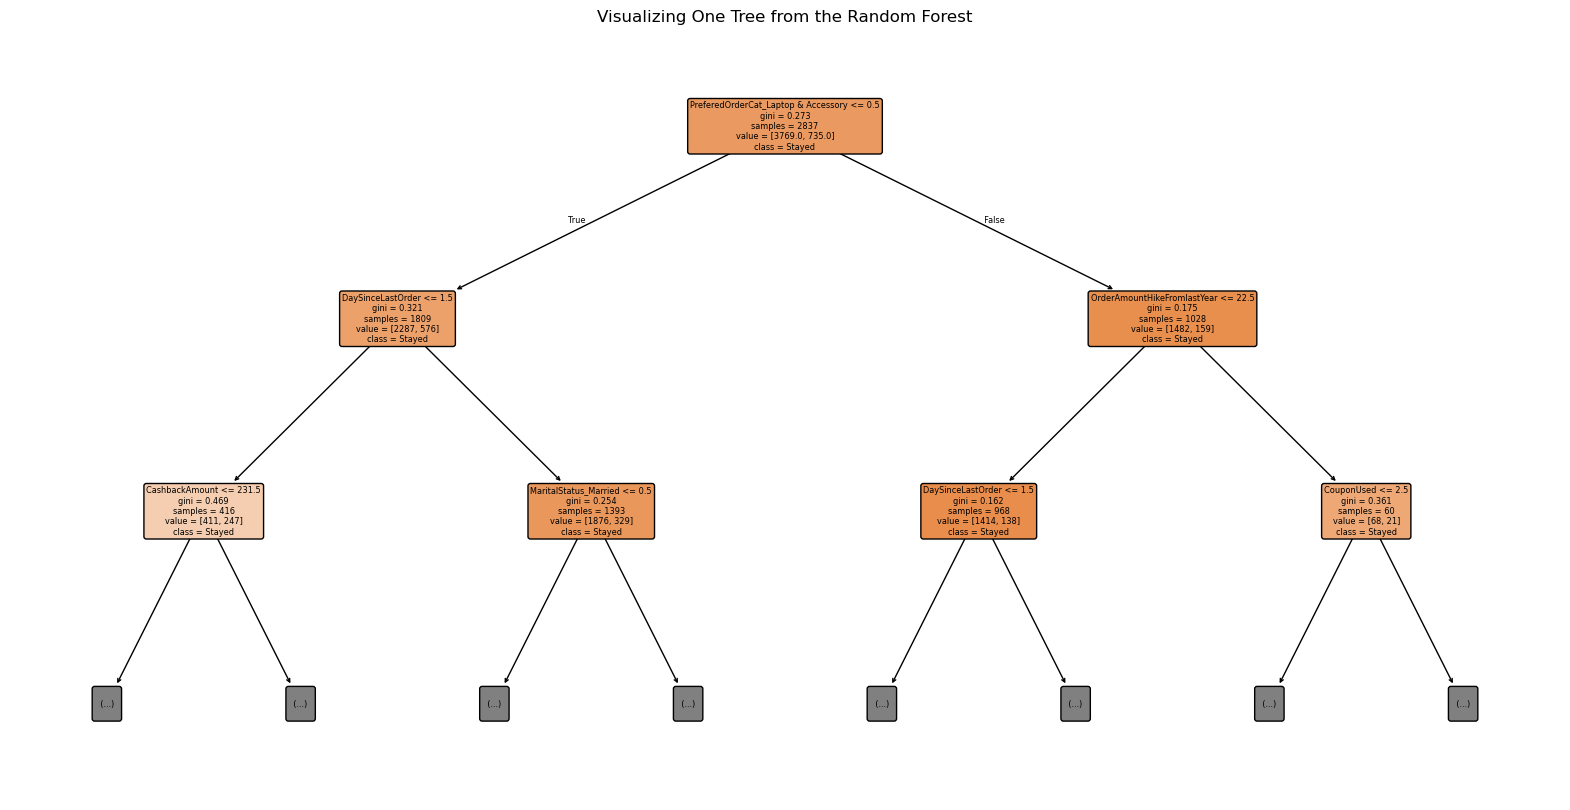

In [36]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# We pick the very first tree (index 0) from the forest
chosen_tree = rf_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(chosen_tree, 
          feature_names=X.columns, 
          class_names=['Stayed', 'Churned'], 
          filled=True, 
          rounded=True, 
          max_depth=2) # We only show the first 2 levels so it's not too crowded
plt.title("Visualizing One Tree from the Random Forest")
plt.show()

Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [44]:
df['CashbackAmount_Log'] = np.log1p(df['CashbackAmount'])

In [45]:
if 'CashbackAmount' in df.columns:
    df.drop('CashbackAmount', axis=1, inplace=True)

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize and Train
log_model = LogisticRegression(max_iter=1000) # Increased max_iter to ensure it converges
log_model.fit(X_train_scaled, y_train)

# 6. Predict and Evaluate
y_pred = log_model.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.2%}")

Logistic Regression Accuracy: 91.47%


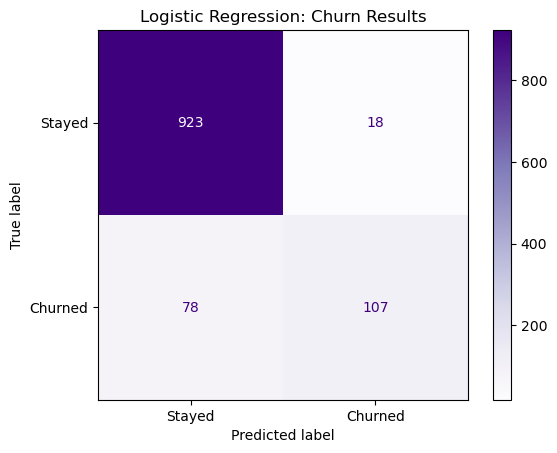

In [47]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Purples') # Different color to distinguish from Random Forest
plt.title('Logistic Regression: Churn Results')
plt.show()

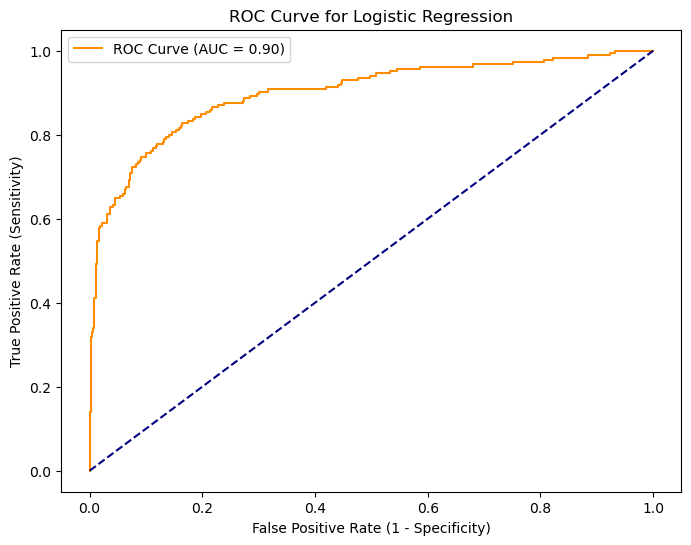

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get the probabilities of churn (class 1)
y_probs = log_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Random guess line
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.show()